# AI based cyberbullying detection system



# Load Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/FinalYearProject/Datasets/output.csv')
df

,Unnamed: 0,text,label,final_label
0,0,#Quran\n #Qurantime \n#QuranHour #quran_thediv...,eng_religion,abusive
1,1,t'as pas honte d'opprimer les gens comme ça es...,fre_bully,bullying
2,2,सबरीमाला में महिलाओं के प्रवेश पर सुप्रीम कोर्...,hin_fake,sarcastic
3,3,@Main_Amitabh @SanjayAzadSln @ArvindKejriwal य...,hin_offense,abusive
4,4,@USER Ne yani kendini affetir macimi bu ? 4 ki...,tur_nonbully,bullying
...,...,...,...,...
33905,33905,“”,chi_nonbully,bullying
33906,33906,@narendramodi @netanyahu सीरिया पाकिस्तान से भ...,hin_fake,sarcastic
33907,33907,"আল্লাহ তাকে হেদায়াত করো, হেদায়াতের মালিক তো তু...",ben_sexual,abusive
33908,33908,you can literally do almost anything to anyone...,eng_neutral,neutral


# **Data Preparation**

## Data separation as X and Y

In [ ]:
y= df['final_label']
y

,final_label
0,abusive
1,bullying
2,sarcastic
3,abusive
4,bullying
...,...
33905,bullying
33906,sarcastic
33907,abusive
33908,neutral


In [ ]:
x=df['text']
x

,text
0,#Quran\n #Qurantime \n#QuranHour #quran_thediv...
1,t'as pas honte d'opprimer les gens comme ça es...
2,सबरीमाला में महिलाओं के प्रवेश पर सुप्रीम कोर्...
3,@Main_Amitabh @SanjayAzadSln @ArvindKejriwal य...
4,@USER Ne yani kendini affetir macimi bu ? 4 ki...
...,...
33905,“”
33906,@narendramodi @netanyahu सीरिया पाकिस्तान से भ...
33907,"আল্লাহ তাকে হেদায়াত করো, হেদায়াতের মালিক তো তু..."
33908,you can literally do almost anything to anyone...


## Data Spliting

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=257)

In [ ]:
x_train

,text
26420,lazarentuuuuu
28079,"Yes, the Old Testament condemns them to death ..."
28969,@beingarun28 @Atheist_Krishna साले को संसद के ...
11372,@ChandreshBaudd1 मैं अपनी नंबर किसी को नहीं दी...
4934,Das wird die nächste Klatsche für die Merkel-T...
...,...
11572,la dernière phrase est tellement vrai il vraim...
14381,তুই তো বাংলার নাস্তিক তোরে পাইলে জুতা দিয়ে পিটতাম
7509,"""Algún espíritu así, hábita ya en , pero segui..."
1174,@anuragkashyap72 साला तेरे माँ बाप कैसे होंगे ...


In [ ]:
x_test

,text
21629,8
32423,আহারে ভারতের বিপক্ষে বলাতে কিছু লোকের জ্বলতেছে
111,भारत-चीन सीमा पर तनाव बढ़ने के कारण अरुणाचल प्र...
8612,..
14243,"""Bandido tem que se fuder e acabou!!"""
...,...
12853,मायावती सीधे सीधे राजस्थान में बीजेपी को सपोर्...
19812,@user g un prof d’eco doctorant et chercheur i...
24145,Год сижу на 4х. В режиме чтения Пикабу и просм...
7436,Cezaİndirimi MecliseGelsin @USER @USER @...


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train and y_test
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Tokenization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

# Fill NaN values with an empty string
x_train_processed = x_train.fillna('')
x_test_processed = x_test.fillna('')

x_train_vectorized = tfidf.fit_transform(x_train_processed)
x_test_vectorized = tfidf.transform(x_test_processed)

print("Shape of x_train_vectorized:", x_train_vectorized.shape)
print("Shape of x_test_vectorized:", x_test_vectorized.shape)

Shape of x_train_vectorized: (27128, 91652)
Shape of x_test_vectorized: (6782, 91652)


# **Model Building**

### **LogisticRegression**

In [ ]:
from sklearn.linear_model import LogisticRegression


# Initialize Logistic Regression model
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_vectorized, y_train_encoded)

LogisticRegression(max_iter=1000)

### Apply the model and prediction




In [ ]:
y_lr_train_pred = lr.predict(x_train_vectorized)
y_lr_test_pred = lr.predict(x_test_vectorized)


In [ ]:
print(y_lr_test_pred)
print(y_test_encoded)

[1 2 0 ... 1 1 2]
[1 2 3 ... 1 1 0]


### **Evaluate Model**

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

lr_train_mse = mean_squared_error(y_train_encoded, y_lr_train_pred)
lr_train_r2 = r2_score(y_train_encoded, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test_encoded, y_lr_test_pred)
lr_test_r2 = r2_score(y_test_encoded, y_lr_test_pred)

In [ ]:
lr_result = pd.DataFrame([['Logistic Regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]],
                           columns=['Model', 'Train MSE', 'Train R2', 'Test MSE', 'Test R2'])
lr_result

,Model,Train MSE,Train R2,Test MSE,Test R2
0,Logistic Regression,0.237209,0.510359,0.352256,0.263277


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test_encoded, y_lr_test_pred, target_names=le.classes_)

print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

     abusive       0.83      0.77      0.80      1167
    bullying       0.95      0.98      0.97      4060
     neutral       0.83      0.83      0.83      1365
   sarcastic       0.58      0.37      0.45       190

    accuracy                           0.90      6782
   macro avg       0.80      0.74      0.76      6782
weighted avg       0.89      0.90      0.90      6782



# Data visulazation of result

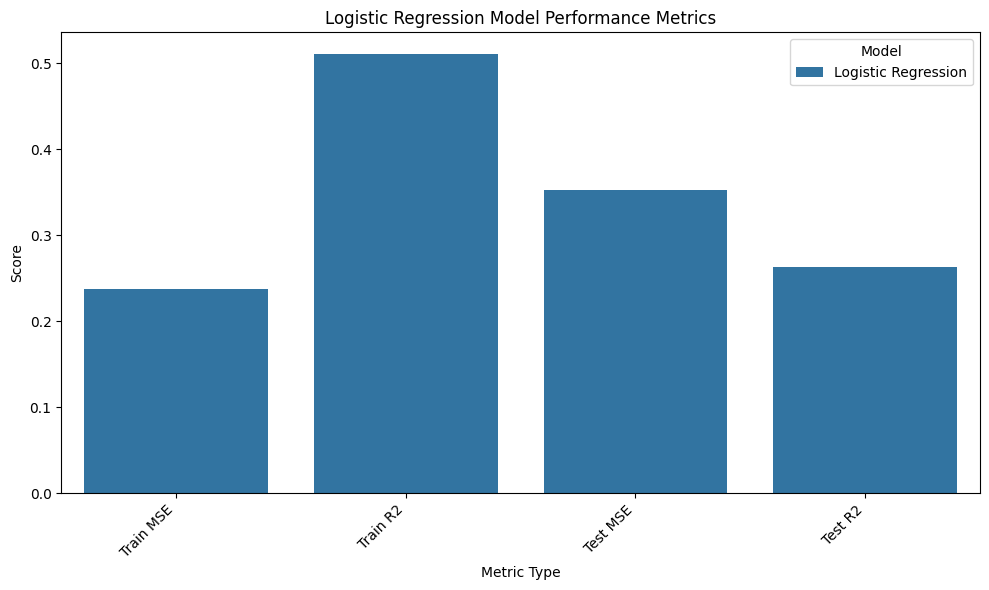

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame for easier plotting with seaborn
metrics_melted = lr_result.melt(id_vars=['Model'], var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melted)
plt.title('Logistic Regression Model Performance Metrics')
plt.ylabel('Score')
plt.xlabel('Metric Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

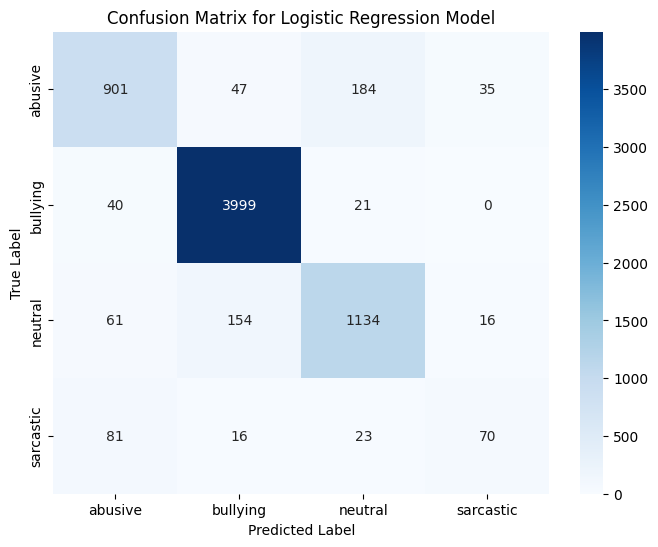

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_lr_test_pred)

# Get the class labels from the LabelEncoder
class_labels = le.classes_

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()